In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import ks_2samp

data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")
data["time"] = pd.to_datetime(data["time"])
data = data.sort_values("time").reset_index(drop=True)
data = data.set_index("time")

15 — Time-Series Decomposition: Splits the PM2.5 series into trend, seasonal (daily), and residual components to see how much of the variation is structural versus random.

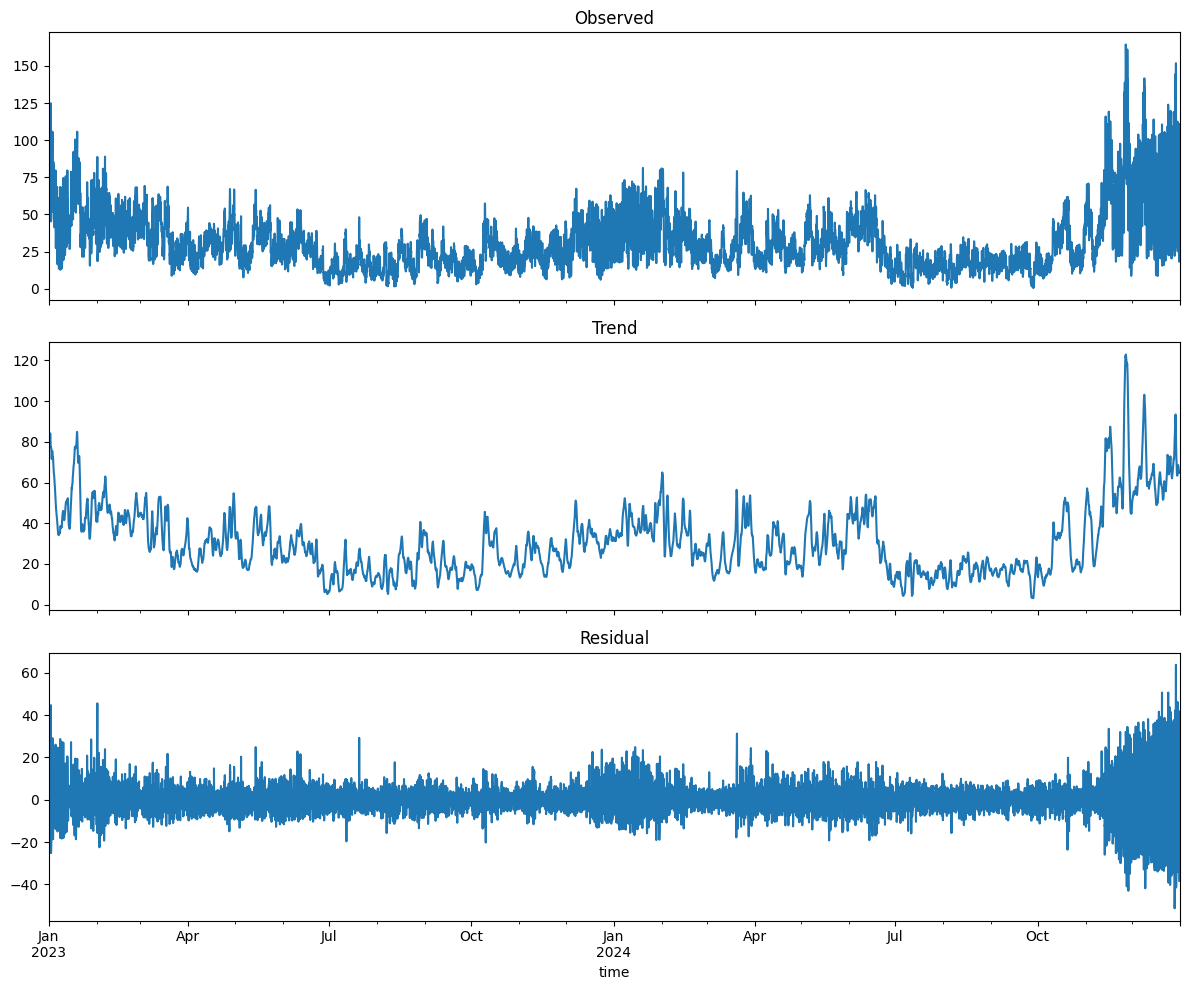

In [2]:
result = seasonal_decompose(data["pm2_5"], model="additive", period=24)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
result.observed.plot(ax=axes[0], title="Observed")
result.trend.plot(ax=axes[1], title="Trend")
result.resid.plot(ax=axes[2], title="Residual")
plt.tight_layout()
plt.show()

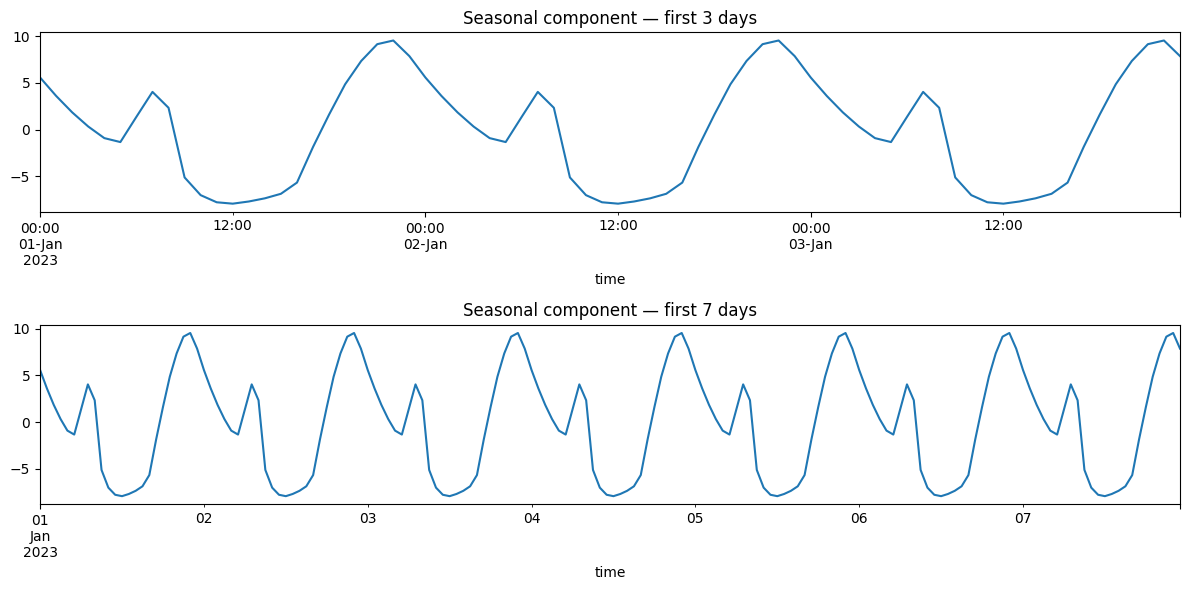

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
result.seasonal.iloc[:24*3].plot(ax=axes[0], title="Seasonal component — first 3 days")
result.seasonal.iloc[:24*7].plot(ax=axes[1], title="Seasonal component — first 7 days")
plt.tight_layout()
plt.show()

16 — Stationarity Testing (ADF/KPSS): Checks whether the statistical properties of PM2.5 (mean, variance) stay constant over time, which determines whether ARIMA-family models need differencing.


In [4]:
adf_stat, adf_p, *_ = adfuller(data["pm2_5"])
print(f"ADF Statistic: {adf_stat:.4f}, p-value: {adf_p:.4f}")
print("ADF conclusion:", "Stationary" if adf_p < 0.05 else "Non-stationary")

kpss_stat, kpss_p, *_ = kpss(data["pm2_5"], regression="c", nlags="auto")
print(f"\nKPSS Statistic: {kpss_stat:.4f}, p-value: {kpss_p:.4f}")
print("KPSS conclusion:", "Non-stationary" if kpss_p < 0.05 else "Stationary")

ADF Statistic: -5.8642, p-value: 0.0000
ADF conclusion: Stationary

KPSS Statistic: 1.4618, p-value: 0.0100
KPSS conclusion: Non-stationary


C:\Users\adars\AppData\Local\Temp\ipykernel_13364\3748553825.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(data["pm2_5"], regression="c", nlags="auto")


17 — Pearson Correlation: Measures the strength of linear relationships between PM2.5 and every other numeric variable.

In [5]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
pearson_corr = data[numeric_cols].corr(method="pearson")

print("Pearson correlation with pm2_5:")
print(pearson_corr["pm2_5"].sort_values(ascending=False))

Pearson correlation with pm2_5:
pm2_5                   1.000000
pm10                    0.952177
sulphur_dioxide         0.753975
carbon_monoxide         0.620771
nitrogen_dioxide        0.493972
surface_pressure        0.175934
relative_humidity_2m    0.045576
ozone                  -0.019743
wind_direction_10m     -0.109160
wind_speed_10m         -0.110932
temperature_2m         -0.522716
Name: pm2_5, dtype: float64


18 — Spearman Correlation: Measures monotonic (not necessarily linear) relationships between PM2.5 and other variables, catching patterns Pearson might miss.


In [7]:
spearman_corr = data[numeric_cols].corr(method="spearman")

print("Spearman correlation with pm2_5:")
print(spearman_corr["pm2_5"].sort_values(ascending=False))

Spearman correlation with pm2_5:
pm2_5                   1.000000
pm10                    0.984206
sulphur_dioxide         0.660291
carbon_monoxide         0.628313
nitrogen_dioxide        0.412267
surface_pressure        0.218198
ozone                   0.050449
relative_humidity_2m   -0.047194
wind_direction_10m     -0.077613
wind_speed_10m         -0.078430
temperature_2m         -0.516114
Name: pm2_5, dtype: float64


19 — Correlation Heatmap: Visualizes the full Pearson correlation matrix across all variables at once, making it easy to spot the strongest relationships.

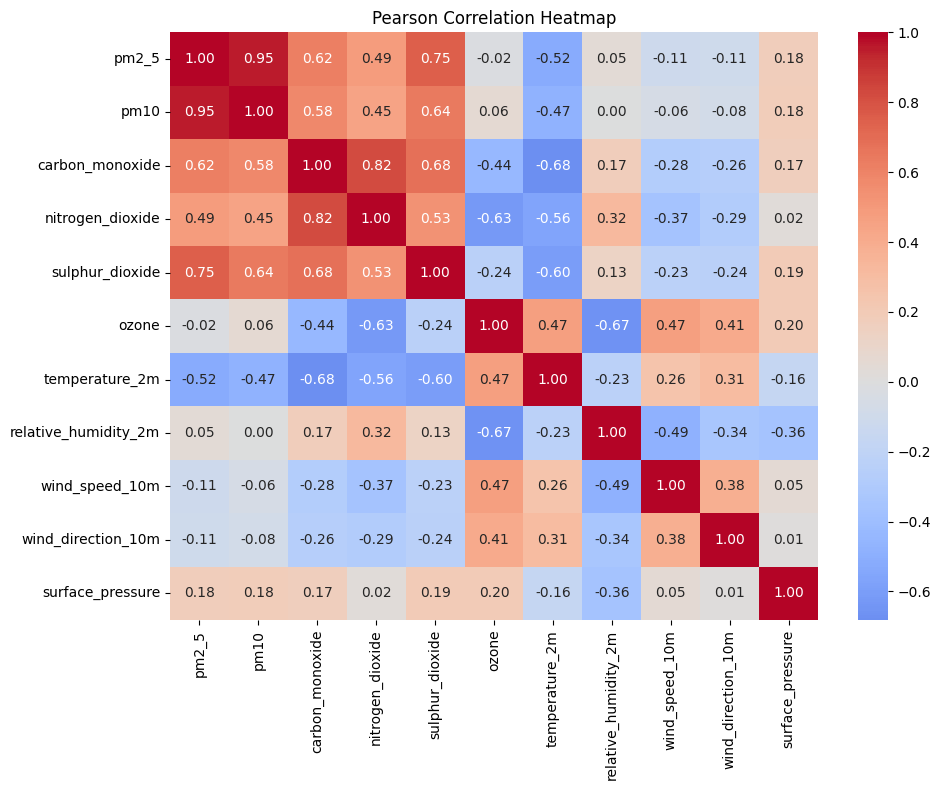

In [8]:
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson Correlation Heatmap")
plt.tight_layout()
plt.show()

20 — ACF (Autocorrelation Function): Shows how strongly PM2.5 correlates with its own past values at every lag, revealing overall temporal dependency and periodicity.


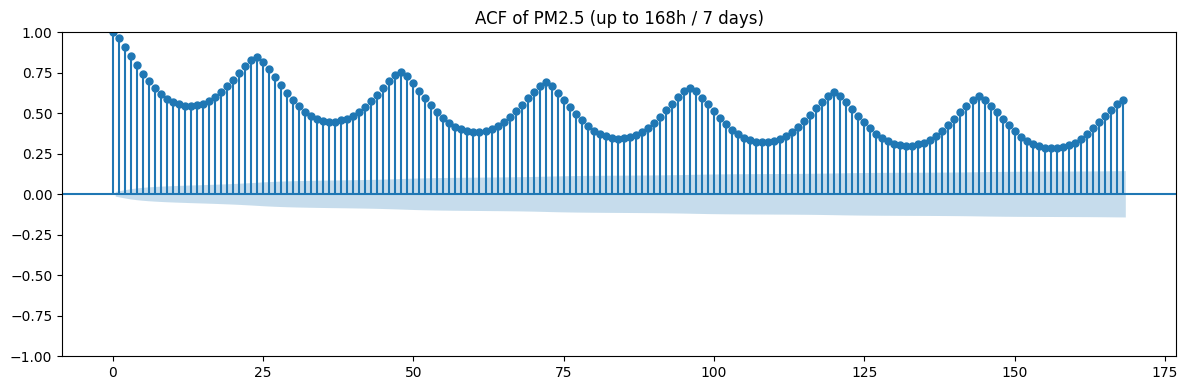

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(data["pm2_5"], lags=168, ax=ax)
plt.title("ACF of PM2.5 (up to 168h / 7 days)")
plt.tight_layout()
plt.show()